# Deteksi & Koreksi Typo Bahasa Indonesia — *Traditional Machine Learning*

**Tujuan:** membangun sistem yang (1) **mendeteksi** apakah sebuah kata/kalimat
mengandung typo, dan (2) **mengoreksi** typo tersebut — **tanpa deep learning**
(tanpa neural network, transformer, RNN, LSTM, maupun BERT).

**Model yang dipakai (klasik):** Logistic Regression, (Complement) Naive Bayes,
Linear SVM, dan XGBoost.

**Ringkasan pendekatan**
1. Inspeksi & pembersihan dataset (18 file CSV pasangan kalimat benar↔salah).
2. Membangun **kamus kata benar** + **pasangan kata (salah→benar)** via penyelarasan.
3. **Deteksi level-KATA**: klasifikasi kata valid vs typo (TF-IDF n-gram karakter).
4. **Deteksi level-KALIMAT**: klasifikasi kalimat benar vs mengandung typo
   (TF-IDF n-gram kata + karakter) — mampu menangkap *real-word error*.
5. **Koreksi (non-DL)**: edit distance (Damerau-Levenshtein) + kemiripan n-gram
   (cosine TF-IDF) + frekuensi + pola keyboard.
6. Evaluasi (akurasi, presisi, recall, F1, confusion matrix) + simpan artefak.
7. **Menu interaktif** untuk pengujian.

> Catatan: seluruh komentar & keluaran dalam **Bahasa Indonesia**.


## 1. Setup & Import Library

In [2]:
# Pasang pandas bila belum tersedia (library lain sudah ada di environment).
# Baris ini aman dijalankan berulang; akan dilewati bila pandas sudah terpasang.
try:
    import pandas  # noqa: F401
except ImportError:
    %pip install -q pandas

import os
import re
import glob
import math
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

# Fungsi util & kelas inti dari pustaka bersama (dipakai ulang oleh typo_app.py).
from typo_lib import (tokenize, damerau_levenshtein, word_shape_features,
                      TypoCorrector, run_menu)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42          # demi hasil yang dapat direproduksi
np.random.seed(RANDOM_STATE)
print("Semua library berhasil diimpor.")


Semua library berhasil diimpor.


## 2. Memuat Dataset

Dataset terdiri dari **18 file CSV** di folder `dataset/`, gabungan dari:
- 3 mata pelajaran (`Pelajaran`): Bahasa Indonesia, IPA, IPS
- 6 jenis kesalahan (`tipe_kesalahan`): Deletion, Insertion, Subtitution,
  Transposition, Punctuation, Real word.

Setiap baris berisi pasangan: `kalimat_awal` (BENAR) dan `kalimat_salah` (mengandung 1 typo).


In [3]:
# Baca seluruh file CSV lalu gabungkan menjadi satu DataFrame.
csv_files = sorted(glob.glob(os.path.join("dataset", "*.csv")))
print(f"Jumlah file CSV ditemukan: {len(csv_files)}")

frames = [pd.read_csv(f, encoding="utf-8") for f in csv_files]
df = pd.concat(frames, ignore_index=True)

print(f"Total baris gabungan : {len(df):,}")
print(f"Kolom                : {list(df.columns)}")
df.head()


Jumlah file CSV ditemukan: 18
Total baris gabungan : 387,000
Kolom                : ['kalimat_awal', 'kalimat_salah', 'Pelajaran', 'tipe_kesalahan']


,kalimat_awal,kalimat_salah,Pelajaran,tipe_kesalahan
0,Bunyi apa?,Buni apa?,Bahasa Indonesia,Deletion Error
1,Siap-siap belajar.,Sia-siap belajar.,Bahasa Indonesia,Deletion Error
2,Diskusikan gambar sampul di atas dengan menjaw...,Diskusikan gambar sampul di atas dengan menawa...,Bahasa Indonesia,Deletion Error
3,Apa yang kalian lihat pada gambar di atas?,Apa yang kalian lihat pada gambar d atas?,Bahasa Indonesia,Deletion Error
4,"Menurut kalian, apa isi ceritanya?","Menurut kalian, apa si ceritanya?",Bahasa Indonesia,Deletion Error


## 3. Inspeksi Dataset (EDA)

In [4]:
# Struktur & tipe data.
print("=== INFO DATAFRAME ===")
df.info()

print("\n=== JUMLAH NILAI KOSONG (missing) PER KOLOM ===")
print(df.isnull().sum())

print("\n=== JUMLAH BARIS DUPLIKAT ===")
print(int(df.duplicated().sum()))


=== INFO DATAFRAME ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387000 entries, 0 to 386999
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   kalimat_awal    387000 non-null  object
 1   kalimat_salah   387000 non-null  object
 2   Pelajaran       387000 non-null  object
 3   tipe_kesalahan  387000 non-null  object
dtypes: object(4)
memory usage: 11.8+ MB

=== JUMLAH NILAI KOSONG (missing) PER KOLOM ===
kalimat_awal      0
kalimat_salah     0
Pelajaran         0
tipe_kesalahan    0
dtype: int64

=== JUMLAH BARIS DUPLIKAT ===
0


In [5]:
# Distribusi per mata pelajaran dan per jenis kesalahan.
print("=== Distribusi per Pelajaran ===")
print(df["Pelajaran"].value_counts())
print("\n=== Distribusi per tipe_kesalahan ===")
print(df["tipe_kesalahan"].value_counts())


=== Distribusi per Pelajaran ===
Pelajaran
Bahasa Indonesia    129000
IPA                 129000
IPS                 129000
Name: count, dtype: int64

=== Distribusi per tipe_kesalahan ===
tipe_kesalahan
Deletion Error         64500
Insertion Error        64500
Punctuation Error      64500
Real word Error        64500
Subtitution Error      64500
Transposition Error    64500
Name: count, dtype: int64


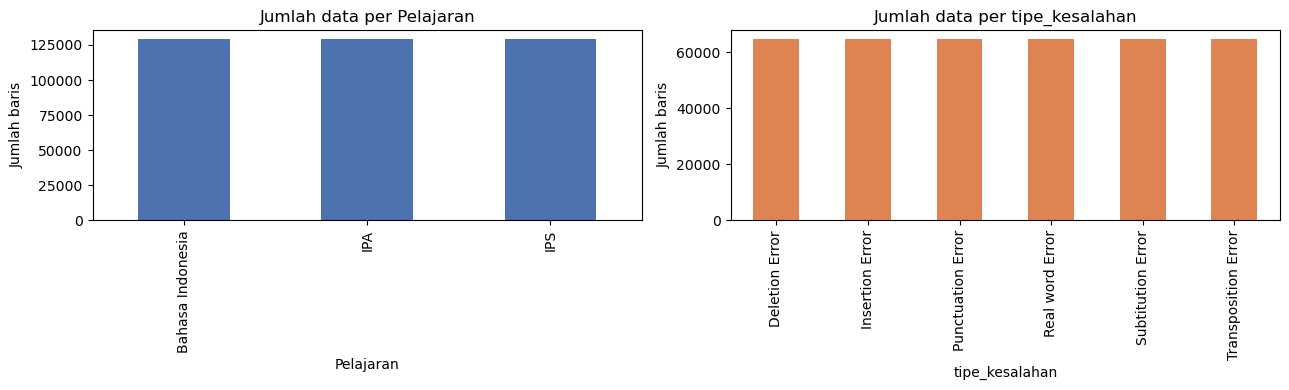

In [6]:
# Visualisasi distribusi (bar chart) memakai matplotlib.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["Pelajaran"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Jumlah data per Pelajaran")
axes[0].set_ylabel("Jumlah baris")
df["tipe_kesalahan"].value_counts().plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Jumlah data per tipe_kesalahan")
axes[1].set_ylabel("Jumlah baris")
plt.tight_layout()
plt.show()


In [7]:
# Contoh pasangan kalimat benar vs salah untuk tiap jenis kesalahan.
for tipe in df["tipe_kesalahan"].unique():
    contoh = df[df["tipe_kesalahan"] == tipe].iloc[0]
    print(f"[{tipe}]")
    print(f"   BENAR : {contoh['kalimat_awal']}")
    print(f"   SALAH : {contoh['kalimat_salah']}\n")


[Deletion Error]
   BENAR : Bunyi apa?
   SALAH : Buni apa?

[Insertion Error]
   BENAR : Bunyi apa?
   SALAH : Bunyti apa?

[Punctuation Error]
   BENAR : Bunyi apa?
   SALAH : Bunyi apa'

[Real word Error]
   BENAR : Bunyi apa?
   SALAH : Bunyi ala?

[Subtitution Error]
   BENAR : Bunyi apa?
   SALAH : Bunyx apa?

[Transposition Error]
   BENAR : Bunyi apa?
   SALAH : Ybuni apa?



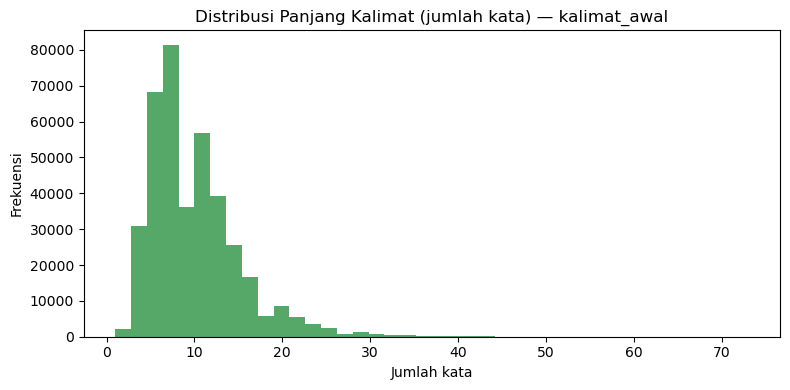

count    387000.000000
mean          9.900465
std           5.154054
min           1.000000
25%           6.000000
50%           9.000000
75%          12.000000
max          73.000000
Name: panjang_kata, dtype: float64


In [8]:
# Distribusi panjang kalimat (jumlah kata) pada kalimat benar.
df["panjang_kata"] = df["kalimat_awal"].apply(lambda s: len(tokenize(s)))
plt.figure(figsize=(8, 4))
plt.hist(df["panjang_kata"], bins=40, color="#55A868")
plt.title("Distribusi Panjang Kalimat (jumlah kata) — kalimat_awal")
plt.xlabel("Jumlah kata")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()
print(df["panjang_kata"].describe())


## 4. Pembersihan Data

Langkah pembersihan **menjaga makna & struktur asli** dataset:
- Rapikan spasi berlebih (strip).
- Buang baris dengan nilai kosong (jika ada).
- Buang baris duplikat persis.
- Buang baris yang `kalimat_awal` == `kalimat_salah` (tidak ada perbedaan untuk dipelajari).


In [9]:
baris_awal = len(df)

# Rapikan spasi pada kolom teks.
for col in ["kalimat_awal", "kalimat_salah"]:
    df[col] = df[col].astype(str).str.strip()

# Buang missing values & duplikat.
df = df.dropna(subset=["kalimat_awal", "kalimat_salah"])
df = df.drop_duplicates()

# Buang pasangan yang tidak berbeda (tidak informatif untuk deteksi/koreksi).
df = df[df["kalimat_awal"] != df["kalimat_salah"]].reset_index(drop=True)

print(f"Baris sebelum : {baris_awal:,}")
print(f"Baris sesudah : {len(df):,}")
print(f"Baris dibuang : {baris_awal - len(df):,}")


Baris sebelum : 387,000
Baris sesudah : 382,206
Baris dibuang : 4,794


## 5. Membangun Kamus Kata Benar (Correction Dictionary)

Semua kata pada kolom `kalimat_awal` adalah **kata yang BENAR**. Kita kumpulkan
menjadi `Counter(kata → frekuensi)`. Kamus ini menjadi:
- "alam semesta" kata benar untuk **negatif** (label 0) pada model deteksi kata, dan
- sumber **kandidat koreksi** (hanya menyarankan kata yang pernah muncul sebagai benar).


In [10]:
# Bangun frekuensi kata benar dari SELURUH kalimat_awal yang unik.
kalimat_benar_unik = df["kalimat_awal"].unique()
freq_kata = Counter()
for kal in kalimat_benar_unik:
    freq_kata.update(tokenize(kal))

vocab = sorted(freq_kata.keys())
print(f"Jumlah kalimat benar unik : {len(kalimat_benar_unik):,}")
print(f"Ukuran kosakata (vocab)   : {len(vocab):,}")
print("Contoh 15 kata paling sering:", freq_kata.most_common(15))


Jumlah kalimat benar unik : 64,434
Ukuran kosakata (vocab)   : 25,727
Contoh 15 kata paling sering: [('yang', 21237), ('dan', 16534), ('di', 12789), ('dengan', 8053), ('untuk', 5436), ('pada', 5416), ('dalam', 5299), ('ini', 5237), ('dapat', 5184), ('dari', 5127), ('itu', 4419), ('atau', 3878), ('kamu', 3840), ('adalah', 3809), ('tersebut', 3670)]


## 6. Ekstraksi Pasangan Kata (salah → benar) via Penyelarasan

Untuk tiap pasangan kalimat, kita selaraskan token memakai
`difflib.SequenceMatcher`. Bagian yang `replace`/`delete`/`insert` memberi kita
pasangan **(kata_benar, kata_salah)** yang presisi — robust terhadap perubahan
panjang (deletion/insertion). Pasangan ini dipakai untuk:
- melatih/menguji **deteksi kata** (kata_salah = typo), dan
- mengevaluasi **koreksi** (target = kata_benar).


In [11]:
from difflib import SequenceMatcher

def ekstrak_pasangan_kata(kalimat_benar, kalimat_salah):
    '''Kembalikan daftar (kata_benar, kata_salah) dari satu pasangan kalimat.'''
    a = tokenize(kalimat_benar)
    b = tokenize(kalimat_salah)
    pasangan = []
    sm = SequenceMatcher(a=a, b=b, autojunk=False)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == "replace":
            # Pasangkan kata benar<->salah pada rentang yang berubah.
            for k in range(max(i2 - i1, j2 - j1)):
                wb = a[i1 + k] if i1 + k < i2 else ""
                ws = b[j1 + k] if j1 + k < j2 else ""
                if wb and ws and wb != ws:
                    pasangan.append((wb, ws))
        elif tag == "delete":
            # Kata hilang di kalimat salah (deletion error pada level kata).
            for k in range(i1, i2):
                pasangan.append((a[k], ""))   # "" = kata terhapus
        elif tag == "insert":
            for k in range(j1, j2):
                pasangan.append(("", b[k]))   # kata tersisip
    return pasangan

# Bangun DataFrame pasangan kata berlabel jenis kesalahan.
records = []
for benar, salah, tipe in zip(df["kalimat_awal"], df["kalimat_salah"], df["tipe_kesalahan"]):
    for wb, ws in ekstrak_pasangan_kata(benar, salah):
        records.append((wb, ws, tipe))

pairs = pd.DataFrame(records, columns=["kata_benar", "kata_salah", "tipe_kesalahan"])
print(f"Total pasangan kata terekstrak: {len(pairs):,}")
pairs.head(10)


Total pasangan kata terekstrak: 329,723


,kata_benar,kata_salah,tipe_kesalahan
0,bunyi,buni,Deletion Error
1,siap-siap,sia-siap,Deletion Error
2,menjawab,menawab,Deletion Error
3,di,d,Deletion Error
4,isi,si,Deletion Error
5,cerita,ceria,Deletion Error
6,boni,bon,Deletion Error
7,biru,bir,Deletion Error
8,jadi,jad,Deletion Error
9,boni,bon,Deletion Error


## 7. Menyiapkan Data Deteksi Level-KATA

Kita bentuk dataset klasifikasi biner:
- **label 1 (typo)**: `kata_salah` dari jenis kesalahan *ortografis*
  (Deletion, Insertion, Subtitution, Transposition, Punctuation).
  *Real word error* DIKECUALIKAN di sini karena typonya berupa kata valid —
  tidak bisa dibedakan dari fitur kata tunggal (ini ditangani model kalimat).
- **label 0 (benar)**: kata yang diambil dari kosakata benar (`vocab`).

Lalu kita **seimbangkan** kelas dan ambil **subsample** agar pelatihan cepat.


In [12]:
ERROR_ORTOGRAFIS = ["Deletion Error", "Insertion Error", "Subtitution Error",
                    "Transposition Error", "Punctuation Error"]

# --- Positif (typo): kata_salah non-kosong dari error ortografis.
typo_words = pairs[(pairs["tipe_kesalahan"].isin(ERROR_ORTOGRAFIS)) &
                   (pairs["kata_salah"].str.len() > 0)]["kata_salah"]
# Buang typo yang ternyata kata valid (kebetulan ada di vocab) agar label bersih.
vocab_set = set(vocab)
typo_words = [w for w in typo_words if w not in vocab_set]

# --- Batasi jumlah agar pelatihan ringan (balanced subsample).
MAX_PER_KELAS = 40000
rng = np.random.default_rng(RANDOM_STATE)

typo_unique = np.array(sorted(set(typo_words)))
if len(typo_unique) > MAX_PER_KELAS:
    typo_sample = rng.choice(typo_unique, MAX_PER_KELAS, replace=False)
else:
    typo_sample = typo_unique

# --- Negatif (benar): sampel dari vocab, sebanyak jumlah positif (seimbang).
vocab_arr = np.array(vocab)
n_neg = min(len(vocab_arr), len(typo_sample))
benar_sample = rng.choice(vocab_arr, n_neg, replace=False)

X_word = np.concatenate([typo_sample, benar_sample])
y_word = np.concatenate([np.ones(len(typo_sample), dtype=int),
                         np.zeros(len(benar_sample), dtype=int)])

print(f"Jumlah contoh typo (label 1) : {len(typo_sample):,}")
print(f"Jumlah contoh benar (label 0): {len(benar_sample):,}")
print(f"Total data deteksi kata      : {len(X_word):,}")


Jumlah contoh typo (label 1) : 40,000
Jumlah contoh benar (label 0): 25,727
Total data deteksi kata      : 65,727


## 8–9. Fitur & Pelatihan Model Deteksi Level-KATA

**Fitur:** TF-IDF **n-gram karakter** (`analyzer='char_wb'`, `ngram_range=(2,4)`).
N-gram karakter sangat efektif menangkap pola ejaan tak lazim akibat typo.

**Catatan fitur tradisional lain** (panjang kata, rasio vokal, deret konsonan,
edit distance, pola keyboard) ditampilkan pada sel di bawah dan dimanfaatkan pada
tahap **koreksi** (Bagian 14). Untuk *classifier* deteksi, n-gram karakter sudah
menjadi sinyal dominan sehingga pipeline dibuat ringkas & mudah dipakai ulang.

Kita latih & bandingkan **4 model**: Logistic Regression, Complement Naive Bayes,
Linear SVM (dikalibrasi agar punya probabilitas), dan XGBoost.


In [13]:
# Contoh fitur bentuk-kata (untuk pemahaman; dipakai di tahap koreksi).
print("Contoh fitur bentuk-kata:")
for w in ["belajar", "bljar", "bunyti", "ybuni"]:
    print(f"  {w:10s} -> {word_shape_features(w)}")


Contoh fitur bentuk-kata:
  belajar    -> {'panjang': 7, 'rasio_vokal': 0.42857142857142855, 'deret_konsonan_max': 1, 'ada_angka': 0, 'ada_huruf_berulang': 0}
  bljar      -> {'panjang': 5, 'rasio_vokal': 0.2, 'deret_konsonan_max': 3, 'ada_angka': 0, 'ada_huruf_berulang': 0}
  bunyti     -> {'panjang': 6, 'rasio_vokal': 0.3333333333333333, 'deret_konsonan_max': 3, 'ada_angka': 0, 'ada_huruf_berulang': 0}
  ybuni      -> {'panjang': 5, 'rasio_vokal': 0.4, 'deret_konsonan_max': 2, 'ada_angka': 0, 'ada_huruf_berulang': 0}


In [14]:
# Split train/test (stratified) untuk deteksi kata.
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_word, y_word, test_size=0.2, random_state=RANDOM_STATE, stratify=y_word)

def buat_pipeline_kata(clf):
    '''Pipeline = TF-IDF n-gram karakter -> classifier.'''
    return Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4),
                                  min_df=2, max_features=50000)),
        ("clf", clf),
    ])

model_kata = {
    "Logistic Regression": buat_pipeline_kata(
        LogisticRegression(max_iter=1000, C=5.0)),
    "Complement NB": buat_pipeline_kata(ComplementNB()),
    "Linear SVM": buat_pipeline_kata(
        CalibratedClassifierCV(LinearSVC(C=1.0), cv=3)),
    "XGBoost": buat_pipeline_kata(
        XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.3,
                      tree_method="hist", n_jobs=-1, eval_metric="logloss",
                      random_state=RANDOM_STATE)),
}

hasil_kata = {}
for nama, pipe in model_kata.items():
    print(f"Melatih: {nama} ...")
    pipe.fit(Xw_train, yw_train)
    pred = pipe.predict(Xw_test)
    proba = pipe.predict_proba(Xw_test)[:, 1]
    hasil_kata[nama] = {
        "accuracy": accuracy_score(yw_test, pred),
        "precision": precision_score(yw_test, pred),
        "recall": recall_score(yw_test, pred),
        "f1": f1_score(yw_test, pred),
        "roc_auc": roc_auc_score(yw_test, proba),
    }
print("Selesai melatih semua model kata.")


Melatih: Logistic Regression ...
Melatih: Complement NB ...
Melatih: Linear SVM ...
Melatih: XGBoost ...
Selesai melatih semua model kata.


## 10. Evaluasi & Pemilihan Model Deteksi Level-KATA

In [15]:
# Tabel perbandingan metrik antar model.
tabel_kata = pd.DataFrame(hasil_kata).T.sort_values("f1", ascending=False)
print("=== Perbandingan Model Deteksi KATA ===")
display(tabel_kata.style.format("{:.4f}"))

# Pilih model terbaik berdasarkan F1-score.
best_word_name = tabel_kata.index[0]
best_word_model = model_kata[best_word_name]
print(f"\nModel KATA terbaik: {best_word_name} (F1={tabel_kata.loc[best_word_name,'f1']:.4f})")


=== Perbandingan Model Deteksi KATA ===


,accuracy,precision,recall,f1,roc_auc
Linear SVM,0.8293,0.8641,0.8538,0.8589,0.8994
Logistic Regression,0.8269,0.8658,0.8468,0.8562,0.8979
XGBoost,0.7797,0.8187,0.8195,0.8191,0.8649
Complement NB,0.7811,0.8752,0.7468,0.8059,0.8664



Model KATA terbaik: Linear SVM (F1=0.8589)


=== Classification Report — Linear SVM (deteksi KATA) ===
              precision    recall  f1-score   support

       benar       0.78      0.79      0.78      5146
        typo       0.86      0.85      0.86      8000

    accuracy                           0.83     13146
   macro avg       0.82      0.82      0.82     13146
weighted avg       0.83      0.83      0.83     13146



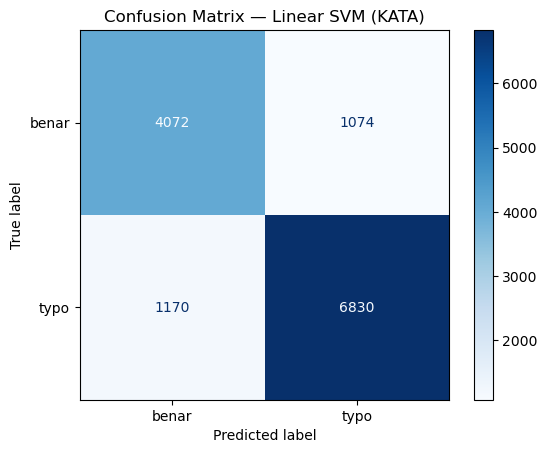

In [16]:
# Confusion matrix & classification report untuk model kata terbaik.
pred_best = best_word_model.predict(Xw_test)
print(f"=== Classification Report — {best_word_name} (deteksi KATA) ===")
print(classification_report(yw_test, pred_best, target_names=["benar", "typo"]))

cm = confusion_matrix(yw_test, pred_best)
ConfusionMatrixDisplay(cm, display_labels=["benar", "typo"]).plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_word_name} (KATA)")
plt.show()


## 11. Menyiapkan Data Deteksi Level-KALIMAT

Sekarang kita bekerja pada **kalimat utuh**:
- **label 0**: `kalimat_awal` (benar)
- **label 1**: `kalimat_salah` (mengandung typo)

Kelebihan model kalimat: ia memakai konteks n-gram kata sehingga **bisa
menangkap real-word error** (kata salah yang sebenarnya kata valid).
Kita ambil subsample berstratifikasi (per pelajaran & tipe kesalahan).


In [17]:
# Subsample berstratifikasi agar ringan namun representatif.
N_PER_TIPE = 2500   # per (pelajaran x tipe_kesalahan) — total puluhan ribu kalimat
contoh = (df.groupby(["Pelajaran", "tipe_kesalahan"], group_keys=False)
            .apply(lambda g: g.sample(min(len(g), N_PER_TIPE), random_state=RANDOM_STATE)))

# Bentuk dataset kalimat: benar (0) + salah (1). Simpan tipe untuk analisis per-error.
benar_df = pd.DataFrame({"teks": contoh["kalimat_awal"], "label": 0,
                         "tipe": "Benar"})
salah_df = pd.DataFrame({"teks": contoh["kalimat_salah"], "label": 1,
                         "tipe": contoh["tipe_kesalahan"]})
data_kalimat = pd.concat([benar_df, salah_df], ignore_index=True)
data_kalimat = data_kalimat.drop_duplicates(subset=["teks", "label"]).reset_index(drop=True)

print(f"Total data kalimat: {len(data_kalimat):,}")
print(data_kalimat["label"].value_counts())


Total data kalimat: 59,108
label
1    44997
0    14111
Name: count, dtype: int64


## 12–13. Fitur & Pelatihan Model Deteksi Level-KALIMAT

**Fitur:** gabungan (`FeatureUnion`) TF-IDF **n-gram kata (1,2)** + **n-gram
karakter (2,4)**. Kita latih & bandingkan 4 model klasik yang sama.


In [18]:
Xs = data_kalimat["teks"].values
ys = data_kalimat["label"].values
tipe_s = data_kalimat["tipe"].values

Xs_train, Xs_test, ys_train, ys_test, tipe_train, tipe_test = train_test_split(
    Xs, ys, tipe_s, test_size=0.2, random_state=RANDOM_STATE, stratify=ys)

def buat_pipeline_kalimat(clf):
    '''Pipeline = (TF-IDF kata + TF-IDF karakter) -> classifier.'''
    fitur = FeatureUnion([
        ("kata", TfidfVectorizer(analyzer="word", ngram_range=(1, 2),
                                 min_df=2, max_features=50000)),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4),
                                 min_df=2, max_features=50000)),
    ])
    return Pipeline([("fitur", fitur), ("clf", clf)])

model_kalimat = {
    "Logistic Regression": buat_pipeline_kalimat(
        LogisticRegression(max_iter=1000, C=5.0)),
    "Complement NB": buat_pipeline_kalimat(ComplementNB()),
    "Linear SVM": buat_pipeline_kalimat(
        CalibratedClassifierCV(LinearSVC(C=1.0), cv=3)),
    "XGBoost": buat_pipeline_kalimat(
        XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.3,
                      tree_method="hist", n_jobs=-1, eval_metric="logloss",
                      random_state=RANDOM_STATE)),
}

hasil_kalimat = {}
for nama, pipe in model_kalimat.items():
    print(f"Train: {nama} ...")
    pipe.fit(Xs_train, ys_train)
    pred = pipe.predict(Xs_test)
    proba = pipe.predict_proba(Xs_test)[:, 1]
    hasil_kalimat[nama] = {
        "accuracy": accuracy_score(ys_test, pred),
        "precision": precision_score(ys_test, pred),
        "recall": recall_score(ys_test, pred),
        "f1": f1_score(ys_test, pred),
        "roc_auc": roc_auc_score(ys_test, proba),
    }
print("Selesai melatih semua model kalimat.")


Train: Logistic Regression ...
Train: Complement NB ...
Train: Linear SVM ...
Train: XGBoost ...
Selesai melatih semua model kalimat.


=== Perbandingan Model Deteksi KALIMAT ===


,accuracy,precision,recall,f1,roc_auc
Linear SVM,0.8334,0.8489,0.9503,0.8968,0.8680
Logistic Regression,0.8099,0.8275,0.9479,0.8836,0.8356
XGBoost,0.7673,0.7850,0.9563,0.8622,0.8232
Complement NB,0.7265,0.7544,0.9500,0.8410,0.4843



Model KALIMAT terbaik: Linear SVM (F1=0.8968)
              precision    recall  f1-score   support

       benar       0.74      0.46      0.57      2822
        typo       0.85      0.95      0.90      9000

    accuracy                           0.83     11822
   macro avg       0.80      0.71      0.73     11822
weighted avg       0.82      0.83      0.82     11822



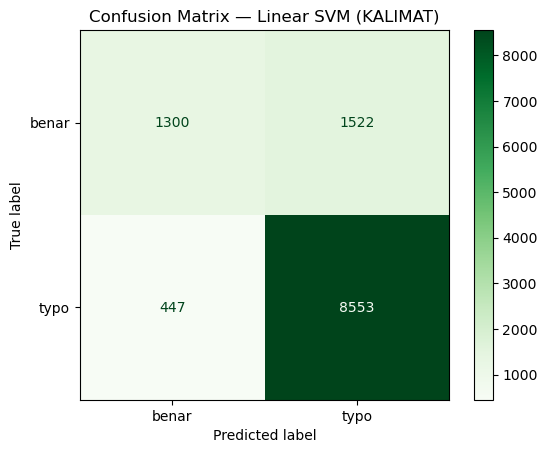

In [19]:
# Perbandingan & pemilihan model kalimat terbaik (berdasarkan F1).
tabel_kalimat = pd.DataFrame(hasil_kalimat).T.sort_values("f1", ascending=False)
print("=== Perbandingan Model Deteksi KALIMAT ===")
display(tabel_kalimat.style.format("{:.4f}"))

best_sent_name = tabel_kalimat.index[0]
best_sent_model = model_kalimat[best_sent_name]
print(f"\nModel KALIMAT terbaik: {best_sent_name} (F1={tabel_kalimat.loc[best_sent_name,'f1']:.4f})")

# Confusion matrix model kalimat terbaik.
pred_s = best_sent_model.predict(Xs_test)
print(classification_report(ys_test, pred_s, target_names=["benar", "typo"]))
cm_s = confusion_matrix(ys_test, pred_s)
ConfusionMatrixDisplay(cm_s, display_labels=["benar", "typo"]).plot(cmap="Greens")
plt.title(f"Confusion Matrix — {best_sent_name} (KALIMAT)")
plt.show()


In [20]:
# Recall per JENIS kesalahan (memperlihatkan kemampuan menangkap real-word error).
mask_typo = ys_test == 1
df_eval = pd.DataFrame({"tipe": tipe_test[mask_typo],
                        "benar_terdeteksi": pred_s[mask_typo] == 1})
recall_per_tipe = df_eval.groupby("tipe")["benar_terdeteksi"].mean().sort_values()
print("=== Recall per tipe kesalahan (model KALIMAT) ===")
print((recall_per_tipe * 100).round(2).astype(str) + " %")


=== Recall per tipe kesalahan (model KALIMAT) ===
tipe
Real word Error        83.64 %
Deletion Error         94.03 %
Transposition Error    97.34 %
Subtitution Error      98.02 %
Insertion Error        98.72 %
Punctuation Error      98.86 %
Name: benar_terdeteksi, dtype: object


## 14. Modul Koreksi (Non-Deep-Learning)

Untuk kata yang ditandai typo, kandidat koreksi dicari dari kosakata benar dengan
menggabungkan beberapa teknik **tradisional**:
1. **Kemiripan cosine** TF-IDF n-gram karakter (mencari bentuk kata yang mirip).
2. **Edit distance** Damerau-Levenshtein (sisip/hapus/substitusi/transposisi).
3. **Frekuensi** kata (kata umum diprioritaskan).
4. **Pola keyboard** QWERTY (bonus untuk salah pencet tombol bersebelahan).

Kita bangun **indeks kemiripan** lalu rakit objek `TypoCorrector` (dari `typo_lib`).


In [21]:
# Indeks kemiripan: TF-IDF n-gram karakter atas SELURUH kosakata benar.
index_vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
index_matrix = index_vectorizer.fit_transform(vocab)   # (n_vocab x n_fitur), L2-normalized
print(f"Indeks kemiripan dibangun: {index_matrix.shape[0]:,} kata, "
      f"{index_matrix.shape[1]:,} fitur n-gram.")

# Rakit TypoCorrector dengan objek in-memory (model terbaik kata & kalimat).
corrector = TypoCorrector(
    word_model=best_word_model,
    sentence_model=best_sent_model,
    correction_freq=dict(freq_kata),
    index_vectorizer=index_vectorizer,
    index_matrix=index_matrix,
    vocab=vocab,
)
print("TypoCorrector siap digunakan.")


Indeks kemiripan dibangun: 25,727 kata, 35,686 fitur n-gram.
TypoCorrector siap digunakan.


In [22]:
# Uji cepat fungsi deteksi & koreksi.
for contoh in ["Buni apa?", "Bunyi apa?", "bljar", "Siswa sedang menulis surat."]:
    d = corrector.detect_typo(contoh)
    s = corrector.suggest_correction(contoh)
    print(f"INPUT   : {contoh}")
    print(f"  deteksi : is_typo={d['is_typo']} | confidence={d['confidence']:.2%}")
    print(f"  koreksi : {s['corrected']}")
    if s["is_typo"]:
        print(f"  saran   : {s['suggestions']}")
    print()


INPUT   : Buni apa?
  deteksi : is_typo=True | confidence=92.91%
  koreksi : Bunyi apa?
  saran   : {'buni': [('bunyi', 0.5788225790683963), ('bung', 0.5584628124421328), ('juni', 0.51415401748949)]}

INPUT   : Bunyi apa?
  deteksi : is_typo=False | confidence=91.05%
  koreksi : Bunyi apa?

INPUT   : bljar
  deteksi : is_typo=True | confidence=89.03%
  koreksi : belajar
  saran   : {'bljar': [('belajar', 0.5388639951234541), ('banjar', 0.4396444305819648), ('blitar', 0.43146248698780426)]}

INPUT   : Siswa sedang menulis surat.
  deteksi : is_typo=False | confidence=78.98%
  koreksi : Siswa sedang menulis surat.



## 15. Evaluasi Koreksi (Top-1 & Top-3 Accuracy)

Kita uji koreksi pada pasangan **(kata_salah → kata_benar)** yang ditahan (held-out).
- **Top-1**: kandidat peringkat 1 = kata benar.
- **Top-3**: kata benar ada di antara 3 kandidat teratas.

Hasil dipecah per jenis kesalahan — *real word error* diperkirakan rendah
(typonya kata valid, sehingga koreksinya ambigu).


In [23]:
# Ambil sampel pasangan koreksi untuk evaluasi (kata_salah valid->benar).
eval_pairs = pairs[(pairs["kata_salah"].str.len() > 0) &
                   (pairs["kata_benar"].str.len() > 0)].copy()
eval_pairs = eval_pairs[eval_pairs["kata_salah"] != eval_pairs["kata_benar"]]
# Subsample agar evaluasi cepat.
eval_sample = eval_pairs.sample(min(4000, len(eval_pairs)), random_state=RANDOM_STATE)

def eval_koreksi(row, k=3):
    cands = [c for c, _ in corrector.candidates(row["kata_salah"], k=k)]
    top1 = bool(cands and cands[0] == row["kata_benar"])
    topk = bool(row["kata_benar"] in cands)
    return pd.Series({"top1": top1, "top3": topk})

hasil_koreksi = eval_sample.join(eval_sample.apply(eval_koreksi, axis=1))
print("=== Akurasi Koreksi (SEMUA pasangan, termasuk real-word) ===")
print(f"Top-1 : {hasil_koreksi['top1'].mean():.2%}")
print(f"Top-3 : {hasil_koreksi['top3'].mean():.2%}")

# Skenario realistis: typo benar-benar DI LUAR kamus (OOV) dgn target dikenal.
# (Real-word error -> typonya kata valid, sehingga koreksinya memang ambigu.)
vset = set(vocab)
oov_mask = (~hasil_koreksi["kata_salah"].isin(vset)) & (hasil_koreksi["kata_benar"].isin(vset))
oov_res = hasil_koreksi[oov_mask]
print(f"\n=== Akurasi Koreksi (khusus typo di luar kamus/OOV, n={len(oov_res):,}) ===")
print(f"Top-1 : {oov_res['top1'].mean():.2%}")
print(f"Top-3 : {oov_res['top3'].mean():.2%}")

print("\n=== Akurasi Koreksi per tipe kesalahan ===")
display((hasil_koreksi.groupby("tipe_kesalahan")[["top1", "top3"]]
         .mean().mul(100).round(2)).style.format("{:.2f}%"))


=== Akurasi Koreksi (SEMUA pasangan, termasuk real-word) ===
Top-1 : 59.08%
Top-3 : 82.55%

=== Akurasi Koreksi (khusus typo di luar kamus/OOV, n=2,922) ===
Top-1 : 79.91%
Top-3 : 90.18%

=== Akurasi Koreksi per tipe kesalahan ===


,top1,top3
tipe_kesalahan,,
Deletion Error,64.47%,89.38%
Insertion Error,94.90%,99.48%
Punctuation Error,1.27%,25.32%
Real word Error,8.93%,71.09%
Subtitution Error,80.53%,87.28%
Transposition Error,55.15%,71.78%


## 16. Menyimpan Artefak (Model, Vectorizer, Kamus)

Semua artefak disimpan ke folder `models/` memakai **joblib** sehingga dapat
dimuat ulang oleh `typo_app.py` (menu terminal) tanpa pelatihan ulang.


In [24]:
# Simpan ringkasan metrik ke metadata config lalu dump semua artefak.
corrector.config["best_word_model"] = best_word_name
corrector.config["best_sentence_model"] = best_sent_name
corrector.config["metrik_kata"] = hasil_kata[best_word_name]
corrector.config["metrik_kalimat"] = hasil_kalimat[best_sent_name]

corrector.save("models")
print("Artefak tersimpan di folder 'models/':")
for f in sorted(os.listdir("models")):
    ukuran = os.path.getsize(os.path.join("models", f)) / 1024
    print(f"  - {f:28s} ({ukuran:,.1f} KB)")


Artefak tersimpan di folder 'models/':
  - correction_dict.joblib       (452.2 KB)
  - correction_index.joblib      (8,002.3 KB)
  - metadata.joblib              (0.6 KB)
  - sentence_model.joblib        (5,618.5 KB)
  - word_model.joblib            (2,235.9 KB)


## 17. Menu Interaktif

Jalankan sel di bawah untuk menguji sistem secara interaktif **di dalam notebook**.
Anda juga bisa menjalankannya dari terminal:

```bash
python typo_app.py
```

Menu akan: menerima kata/kalimat, menampilkan status typo + confidence,
memberi saran koreksi, menolak input kosong, dan bisa menguji banyak input.


In [25]:
# Muat ulang dari disk untuk memastikan artefak tersimpan dapat dipakai,
# lalu buka menu interaktif. (Saat eksekusi otomatis/non-interaktif, menu
# akan berhenti dengan rapi tanpa error.)
corrector_loaded = TypoCorrector.load("models")
run_menu(corrector_loaded)


  SISTEM DETEKSI & KOREKSI TYPO (Traditional ML)

MENU:
  1. Periksa kata / kalimat (deteksi + koreksi)
  2. Keluar
------------------------------------------------------------
Status      : ADA TYPO terdeteksi
Level       : kalimat
Prob. typo  : 99.77% (model kalimat)
Confidence  : 99.77%
Kata salah  : cba
Koreksi     : hawwo iin coba
Saran kandidat (top-k):
   - cba -> coba (0.52), cb (0.48), ba (0.37)
------------------------------------------------------------

MENU:
  1. Periksa kata / kalimat (deteksi + koreksi)
  2. Keluar
------------------------------------------------------------
Status      : ADA TYPO terdeteksi
Level       : kalimat
Prob. typo  : 99.90% (model kalimat)
Confidence  : 99.90%
Kata salah  : halo, test
Koreksi     : hal iin rest
Saran kandidat (top-k):
   - halo -> hal (0.61), halong (0.51), hallo (0.49)
   - test -> rest (0.52), tes (0.49), best (0.47)
------------------------------------------------------------

MENU:
  1. Periksa kata / kalimat (deteksi + kor